<a href="https://colab.research.google.com/github/Gowrav06/Data-Science/blob/main/Time_Series_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [5]:
# Load dataset
df = pd.read_csv("exchange_rate.csv")


In [6]:
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


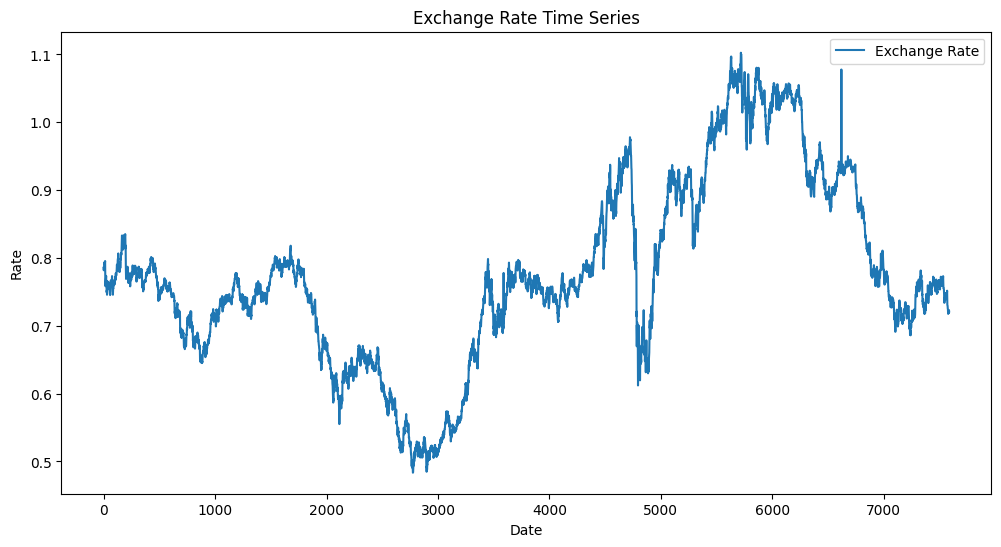

In [9]:
# Plot time series
plt.figure(figsize=(12,6))
plt.plot(df["Ex_rate"], label="Exchange Rate")
plt.title("Exchange Rate Time Series")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.legend()
plt.show()

In [11]:
# Handle missing values
df["Ex_rate"] = df["Ex_rate"].fillna(method="ffill")

# Check stationarity with Augmented Dickey-Fuller test
result = adfuller(df["Ex_rate"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

/tmp/ipykernel_1942/1141324532.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["Ex_rate"] = df["Ex_rate"].fillna(method="ffill")


ADF Statistic: -1.6649941807382342
p-value: 0.4492327353597477


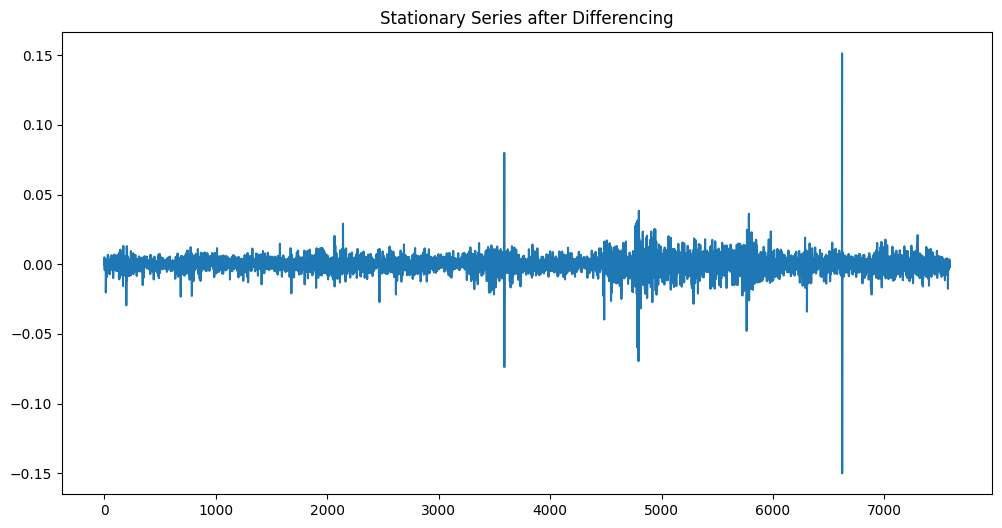

In [13]:
# Differencing if needed
df_diff = df["Ex_rate"].diff().dropna()

plt.figure(figsize=(12,6))
plt.plot(df_diff, label="Differenced Series")
plt.title("Stationary Series after Differencing")
plt.show()

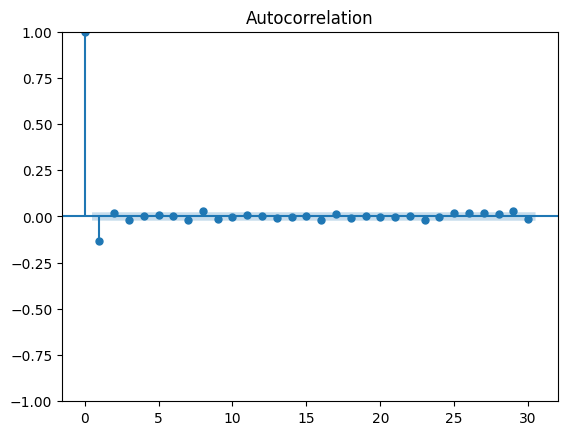

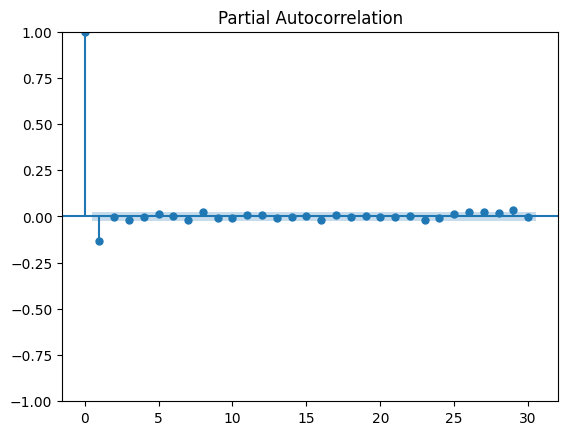

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Fri, 10 Apr 2026   AIC                         -56102.322
Time:                        08:45:43   BIC                         -56081.519
Sample:                             0   HQIC                        -56095.182
                               - 7588                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

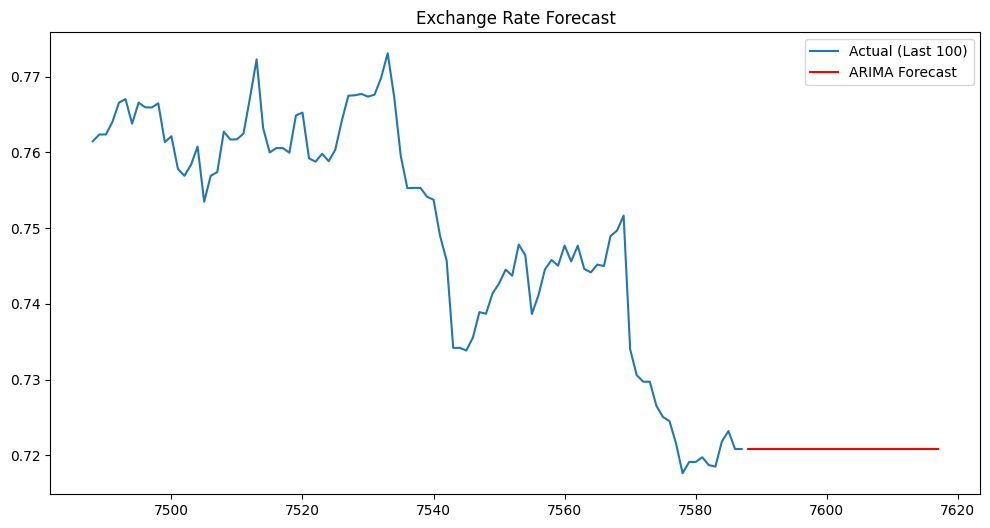

In [15]:
# Plot ACF and PACF to estimate p and q
plot_acf(df_diff, lags=30)
plot_pacf(df_diff, lags=30)
plt.show()

# Fit ARIMA model (example: ARIMA(1,1,1))
# Using the correct column name 'Ex_rate'
model_arima = ARIMA(df["Ex_rate"], order=(1,1,1))
arima_fit = model_arima.fit()

print(arima_fit.summary())

# Forecast
forecast_arima = arima_fit.forecast(steps=30)

plt.figure(figsize=(12,6))
plt.plot(df["Ex_rate"].tail(100), label="Actual (Last 100)")
plt.plot(range(len(df), len(df) + 30), forecast_arima, label="ARIMA Forecast", color='red')
plt.title("Exchange Rate Forecast")
plt.legend()
plt.show()

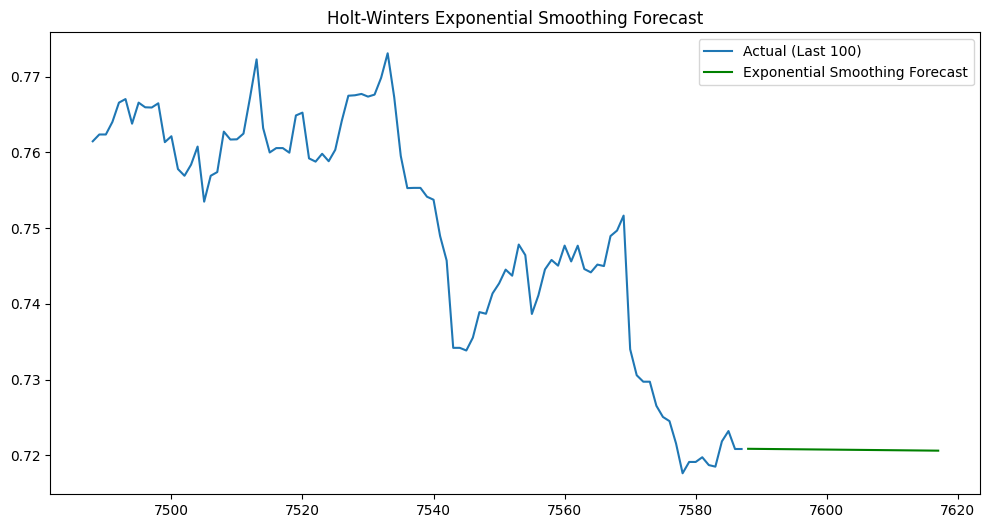

In [17]:
# Fit Holt-Winters Exponential Smoothing
# Using the correct column name 'Ex_rate'
model_es = ExponentialSmoothing(df["Ex_rate"], trend="add", seasonal=None)
es_fit = model_es.fit()

# Forecast
forecast_es = es_fit.forecast(30)

plt.figure(figsize=(12,6))
plt.plot(df["Ex_rate"].tail(100), label="Actual (Last 100)")
plt.plot(range(len(df), len(df) + 30), forecast_es, label="Exponential Smoothing Forecast", color='green')
plt.title("Holt-Winters Exponential Smoothing Forecast")
plt.legend()
plt.show()

In [19]:
# Split train-test
train_size = int(len(df)*0.8)
train, test = df["Ex_rate"][:train_size], df["Ex_rate"][train_size:]

# ARIMA forecast on test
arima_model = ARIMA(train, order=(1,1,1)).fit()
arima_pred = arima_model.forecast(len(test))

# Exponential Smoothing forecast on test
es_model = ExponentialSmoothing(train, trend="add").fit()
es_pred = es_model.forecast(len(test))

# Metrics
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred)/y_true))*100
    print(f"{model_name} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.2f}%")

evaluate(test, arima_pred, "ARIMA")
evaluate(test, es_pred, "Exponential Smoothing")

ARIMA -> MAE: 0.1777, RMSE: 0.2054, MAPE: 22.80%
Exponential Smoothing -> MAE: 0.2066, RMSE: 0.2391, MAPE: 26.51%
